<!-- SPDX-FileCopyrightText: 2026 Orbital Research Cluster for Celestial Applications (ORCCA) Lab, University of Colorado at Boulder -->
<!-- SPDX-License-Identifier: ISC -->
# Measurement Simulation
---
*Scarabaeus | Last revised 2026*

## What this notebook covers
The complete measurement simulation pipeline: initializing sensors and measurement models,
simulating observations on a true trajectory, computing predicted measurements on a
reference trajectory, evaluating partials and residuals, and packaging everything into
filter-ready datasets.

### Topics
| # | Topic |
|---|-------|
| 1 | True and reference trajectories |
| 2 | Sensors — ground stations and camera |
| 3 | Measurement models — Range, Range Rate, Centroiding |
| 4 | Simulating observed measurements (`write_observed_measurements`) |
| 5 | Reading back observed measurements (`observed_measurements`) |
| 6 | Computed measurements on the reference trajectory |
| 7 | Partials (H matrix) and residuals (O−C) |
| 8 | Measurement datasets — filter-ready API |
| 9 | Visualization |


## How to run
Run from the **project root** directory (`scarabaeus/`).

## 0. Imports and Setup

In [1]:
import scarabaeus as scb
import supplementary as supp

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib import cm

# define units and frame
kg, km, sec, rad = scb.Units.get_units(['kg', 'km', 'sec', 'rad'])
J2000 = scb.Frame('J2000')

# load tutorial data
data = supp.load_data()

# tutorial output paths
tut_result_path = Path.cwd() / 'tutorial_results/meas_gen'
(tut_result_path / 'radiometric').mkdir(parents=True, exist_ok=True)
(tut_result_path / 'optical').mkdir(parents=True, exist_ok=True)

# load kernels
scb.SpiceManager.clear_kernels()
scb.SpiceManager.load_kernel_from_mkfile(data.mk.path)

CMAP   = cm.tab10
COLORS = [CMAP(i / 10) for i in range(10)]


SCB supplementary data up to date.


---
## 1. Trajectories — True and Reference

The measurement pipeline requires two trajectories:

| Trajectory | Role |
|---|---|
| **True** | Observations are simulated on this trajectory (`write_observed_measurements`) |
| **Reference** | Predicted (computed) measurements are evaluated on this trajectory; the residual is `observed − computed` |

Both are Earth-orbiting, with the reference perturbed by +1 m / +1 mm/s to mimic
an initial state error.

In [2]:
earth    = scb.CelestialBody.from_constants('EARTH')
unitless = scb.Units.get_units('unitless')

# ── spacecraft ────────────────────────────────────────────────────
def make_sc(name, spice_id):
    return scb.Spacecraft(
        name, spice_id,
        tot_mass  = scb.ArrayWUnits(1500.0, kg),
        area      = scb.ArrayWUnits(1e-6,   km**2),
        ref_coeff = scb.ArrayWUnits(1.5,    unitless),
    )

Orbiter    = make_sc('Orbiter',           -1000)
Orbiter_ref= make_sc('Orbiter_reference', -1001)

# ── epoch array (1-hour arc, 2030-FEB-18) ─────────────────────────
t0 = scb.SpiceManager.str2et('2030-FEB-18 21:48:32.90210 TDB')
tf = t0 + 3600.0
epoch_prop = scb.EpochArray(np.linspace(t0 - 10, tf + 10, 200), sys='TDB')

# ── initial conditions ─────────────────────────────────────────────
pos0 = scb.ArrayWFrame(np.array([7000.0, 0.0, 0.0]),      km,      J2000)
vel0 = scb.ArrayWFrame(np.array([0.0, 7.546049, 0.0]),    km/sec,  J2000)

d_pos = scb.ArrayWUnits(np.array([1e-3, 1e-3, 1e-3]),  km)
d_vel = scb.ArrayWUnits(np.array([1e-6, 1e-6, 1]),   km/sec)
pos_ref = scb.ArrayWFrame(pos0.quantity + d_pos, J2000)
vel_ref = scb.ArrayWFrame(vel0.quantity + d_vel, J2000)

# ── propagate and write SPKs ──────────────────────────────────────
def propagate_and_save(sc, pos, vel, name):
    state_def = scb.StateDefinition.from_components([
        ('position', 3, 'estimated', 'dynamic', sc, pos),
        ('velocity', 3, 'estimated', 'dynamic', sc, vel),
    ])
    sv   = scb.StateArray(epoch=epoch_prop[0], origin=earth, state=state_def)
    fm   = scb.ForceModelTranslation(primary_body=sc)
    prop = scb.Propagator(primary_body=sc, state_vector=sv, tspan=epoch_prop, force_models=fm)
    prop.propagate(display_progress=False)

    spk_path = tut_result_path / name
    if spk_path.exists(): spk_path.unlink()

    scb.Trajectory(state_array=prop.propagated_state_array).write_to_spk(str(spk_path))
    print(f"  SPK written : {spk_path.name}")
    return prop

prop_true = propagate_and_save(Orbiter,     pos0,    vel0,    'meas_true.bsp')
prop_ref  = propagate_and_save(Orbiter_ref, pos_ref, vel_ref, 'meas_ref.bsp')

  SPK written : meas_true.bsp
  SPK written : meas_ref.bsp


---
## 2. Sensors

Scarabaeus separates **sensors** (hardware: ground stations, cameras, antennae) from
**measurement models** (physics: range, range-rate, centroiding, …).

### Ground Stations

`GroundStation(name)` looks up the station's geodetic position from the loaded SPICE
kernels by name.  Any DSN station name recognised by the earthstns frame kernel is valid.

In [3]:
GS1 = scb.GroundStation('DSS-14')   # Goldstone, CA
GS2 = scb.GroundStation('DSS-63')   # Madrid, Spain
print(f"GS1 : {GS1.name}")
print(f"GS2 : {GS2.name}")

GS1 : DSS-14
GS2 : DSS-63


### Camera

`Camera` defines the optical instrument used for centroid-based OpNav measurements.

| Parameter | Description |
|---|---|
| `fov_angular` | Half-angle field of view [rad] in (x, y) |
| `fov_pixels` | Detector resolution (px × px) |
| `ifov_angle` | Instantaneous field of view per pixel [rad/px] |
| `focal_length` | Focal length [km] |

The camera is attached to the spacecraft via `Spacecraft.add_instrument([camera])`.

In [4]:
cam_kwargs = dict(
    camera_frame  = J2000,
    fov_angular   = scb.ArrayWUnits(np.deg2rad(np.array([2.5, 2.5])), rad),
    fov_pixels    = (2000, 2000),
    ifov_angle    = scb.ArrayWUnits(np.array([25e-6, 20e-6]), rad),   # rad/pixel
    focal_length  = scb.ArrayWUnits(150e-6, km),                      # 150 mm
)

Camera     = scb.Camera(name='ORCCA_cam',      associated_body_spice_id=Orbiter.spice_id,     **cam_kwargs)
Camera_ref = scb.Camera(name='ORCCA_cam_ref',  associated_body_spice_id=Orbiter_ref.spice_id, **cam_kwargs)

Orbiter.add_instrument([Camera])
Orbiter_ref.add_instrument([Camera_ref])

# ── optical navigation target body ───────────────────────────────
opnav_target = scb.Body(name='VENUS', spice_id=299)
print(f"OpNav target : {opnav_target.name}")

OpNav target : VENUS


---
## 3. Measurement Models

Each model pairs a sensor with a physical observation type and a noise standard deviation.

| Model class | Sensor | Observable | Unit |
|---|---|---|---|
| `RangeIdeal` | `GroundStation` | Two-way range | km |
| `RangeRateIdeal` | `GroundStation` | Two-way range rate | km/s |
| `DopplerIdeal` | `GroundStation` + `Antenna` | Doppler shift (2W or 3W) | Hz *(not covered here)* |
| `DiffOneWayRangeIdeal` | Two `GroundStation`s | Differential one-way range (DOR) | s *(not covered here)* |
| `CentroidingIdeal` | `Camera` | Pixel centroid of body | px |

In [5]:
# ── measurement sigmas ────────────────────────────────────────────
range_sigma       = scb.ArrayWUnits(1e-3,              km)
rangerate_sigma   = scb.ArrayWUnits(1e-5,              km/sec)
centroid_sigma    = scb.ArrayWUnits(np.array([1., 1.]), None)   # pixels

# ── radiometric models (DSS-14) ───────────────────────────────────
Range_GS1     = scb.RangeIdeal(    name='GS1 Range',     instrument=GS1, sigma=range_sigma)
RangeRate_GS1 = scb.RangeRateIdeal(name='GS1 RangeRate', instrument=GS1, sigma=rangerate_sigma)

# ── optical navigation model ──────────────────────────────────────
Centroid = scb.CentroidingIdeal(name='OpNav centroid', camera=Camera, sigma=centroid_sigma)

print("Models created:")
print(f"  {Range_GS1.name}")
print(f"  {RangeRate_GS1.name}")
print(f"  {Centroid.name}")

Models created:
  GS1 Range
  GS1 RangeRate
  OpNav centroid


---
## 4. Simulating Observed Measurements

`write_observed_measurements(target, epoch_array, noisy, file_name)` evaluates the
measurement model on the **true** trajectory, optionally adds Gaussian noise, and writes
the result to `data/measurements/radiometric/<file_name>.json`.

| Parameter | Description |
|---|---|
| `target` | The spacecraft (or body for OpNav) on whose true trajectory to evaluate |
| `epoch_array` | Measurement epochs |
| `noisy=True` | Add Gaussian noise with the model's σ |
| `file_name` | Output file name (no path, no extension) |
| `check_visibility=True` | Skip epochs where the target is below the elevation mask |
| `elevation_mask` | Minimum elevation angle [deg] for ground-station visibility |

In [6]:
# ── epoch arrays for each model (different cadences) ─────────────
ep_range     = scb.EpochArray(np.linspace(t0, tf,  50),  sys='TDB')
ep_rangerate = scb.EpochArray(np.linspace(t0, tf, 100),  sys='TDB')
ep_opnav     = scb.EpochArray(np.linspace(t0, tf,  10),  sys='TDB')

# ── write noisy observations on the true trajectory ───────────────
Range_GS1.write_observed_measurements(
    target=Orbiter, epoch_array=ep_range, noisy=True,
    file_name='meas_range',
    folder_path_override=str(tut_result_path / 'radiometric'),
)
RangeRate_GS1.write_observed_measurements(
    target=Orbiter, epoch_array=ep_rangerate, noisy=True,
    file_name='meas_rangerate',
    folder_path_override=str(tut_result_path / 'radiometric'),
)
Centroid.write_observed_measurements(
    target=opnav_target, epoch_array=ep_opnav, noisy=True,
    file_name='meas_opnav',
    folder_path_override=str(tut_result_path / 'optical'),
)
print(f"Observed measurements written to {tut_result_path}")


Observed measurements written to /Users/zael5647/scarabaeus/docs/online_documentation/sphinx_files/_collections/tutorials/tutorial_results/meas_gen


---
## 5. Reading Back Observed Measurements

`observed_measurements(file_name, meas_name, units)` reads the JSON written above and
returns a 4-tuple `(epoch_et, epoch_sec, measurements, flags)`.

| Index | Content |
|---|---|
| `[0]` `epoch_et` | `EpochArray` of measurement epochs (TDB, ET) |
| `[1]` `epoch_sec` | Seconds from arc start (ndarray) |
| `[2]` `measurements` | `ArrayWFrame` of observed values |
| `[3]` `flags` | Gap or quality flags (ndarray, zeros = no gaps) |

In [7]:
obs_range     = Range_GS1.observed_measurements(
    file_name=str(tut_result_path / 'radiometric/meas_range.json'),
    meas_name='meas_ideal', units=km,
)
obs_rangerate = RangeRate_GS1.observed_measurements(
    file_name=str(tut_result_path / 'radiometric/meas_rangerate.json'),
    meas_name='meas_ideal', units=km/sec,
)
obs_opnav = Centroid.observed_measurements(
    file_name=str(tut_result_path / 'optical/meas_opnav.json'),
    meas_name='meas_ideal',
)

# observed_measurements returns (epoch_et, epoch_sec, measurements, flags)
ep_range_et,     _, meas_range,     _ = obs_range
ep_rangerate_et, _, meas_rangerate, _ = obs_rangerate
ep_opnav_et,     _, meas_opnav,     _ = obs_opnav

print(f"Range     : {len(ep_range_et)} epochs,  "
      f"mean = {float(meas_range.quantity.values.mean()):.3f} km")
print(f"Range rate: {len(ep_rangerate_et)} epochs,  "
      f"mean = {float(meas_rangerate.quantity.values.mean()):.6f} km/s")
print(f"OpNav     : {len(ep_opnav_et)} epochs,  "
      f"shape = {meas_opnav.quantity.values.shape}  (n_epochs × 2 px)")


Range     : 50 epochs,  mean = 9524.317 km
Range rate: 100 epochs,  mean = 2.275299 km/s
OpNav     : 10 epochs,  shape = (10, 2)  (n_epochs × 2 px)


---
## 6. Computed Measurements on the Reference Trajectory

`computed_measurements(target, epoch_array, frame)` evaluates the noiseless model
prediction on the **reference** trajectory.  The returned 4-tuple is
`(epoch_et, epoch_sec, sigma, computed_values)`.  The residual `observed − computed`
represents the linearised observation error to be corrected by the filter.

In [8]:
_, _, _, comp_range     = Range_GS1.computed_measurements(
    target=Orbiter_ref, epoch_array=ep_range_et,     frame=J2000)
_, _, _, comp_rangerate = RangeRate_GS1.computed_measurements(
    target=Orbiter_ref, epoch_array=ep_rangerate_et, frame=J2000)
_, _, _, comp_opnav     = Centroid.computed_measurements(
    target=opnav_target, epoch_array=ep_opnav_et,   frame=J2000)

print(f"Computed range      shape : {comp_range.quantity.values.shape}")
print(f"Computed range rate shape : {comp_rangerate.quantity.values.shape}")
print(f"Computed OpNav      shape : {comp_opnav.quantity.values.shape}")

Computed range      shape : (50,)
Computed range rate shape : (100,)
Computed OpNav      shape : (10, 2)


---
## 7. Partials and Residuals

### Partials (H matrix)

`compute_partials(target, epoch_array, frame)` returns the measurement partial-derivative
matrix $H_k = \partial h / \partial x$ evaluated at each epoch.  This is the same matrix
the filter uses to map state corrections to measurement corrections.  It is normally
computed internally by `generate_measurement_dataset`, but can be accessed directly here.

### Residuals (O − C)

`residuals(observed, computed)` returns the pre-fit residual vector
$y_k = z_k^\text{obs} - h(x^*(t_k))$ at each epoch.

In [9]:
# ── partials — compute_partials returns a list of lists → stack to ndarray
H_range     = np.array(Range_GS1.compute_partials(    Orbiter_ref, ep_range_et,     J2000))
H_rangerate = np.array(RangeRate_GS1.compute_partials(Orbiter_ref, ep_rangerate_et, J2000))
H_opnav     = np.array(Centroid.compute_partials(     opnav_target, ep_opnav_et,    J2000))

print(f"H range      : {H_range.shape}      (n_meas × n_state)")
print(f"H range rate : {H_rangerate.shape}      (n_meas × n_state)")
print(f"H opnav      : {H_opnav.shape}   (2 × n_epochs × n_state)")

# ── residuals — residuals() returns ArrayWFrame; extract .quantity.values
res_range     = Range_GS1.residuals(    meas_range,     comp_range    ).quantity.values.ravel()
res_rangerate = RangeRate_GS1.residuals(meas_rangerate, comp_rangerate).quantity.values.ravel()
res_opnav     = Centroid.residuals(     meas_opnav,     comp_opnav    ).quantity.values

print(f"\nRMS range residual     : {float(np.sqrt(np.mean(res_range**2))):.4e} km")
print(f"RMS range-rate residual: {float(np.sqrt(np.mean(res_rangerate**2))):.4e} km/s")
print(f"RMS opnav  residual    : {float(np.sqrt(np.mean(res_opnav**2))):.4e} px")


Generating _partials computed measurements...


Partials:   0%|                                                                 | 0/50 obs [00:00<?]

Partials:   2%|█▏                                                           | 1/50 obs [00:00<00:00]

Partials:   4%|██▍                                                          | 2/50 obs [00:00<00:00]

Partials:   6%|███▋                                                         | 3/50 obs [00:00<00:00]

...

Partials: 100%|████████████████████████████████████████████████████████████| 10/10 obs [00:00<00:00]

Partials: 100%|████████████████████████████████████████████████████████████| 10/10 obs [00:00<00:00]

Partials: 100%|████████████████████████████████████████████████████████████| 10/10 obs [00:00<00:00]

H range      : (50, 6)      (n_meas × n_state)
H range rate : (100, 6)      (n_meas × n_state)
H opnav      : (10, 2, 6)   (2 × n_epochs × n_state)



RMS range residual     : 2.8034e+02 km
RMS range-rate residual: 4.1090e-01 km/s
RMS opnav  residual    : 1.3378e+00 px


---
## 8. Measurement Datasets

### `generate_measurement_dataset`

`model.generate_measurement_dataset(name, target, observed_meas)` bundles residuals,
partials, sigmas, and epoch bookkeeping into a `MeasurementDataSet` ready for the filter.

### `MeasurementSpec` — filter-facing API

`MeasurementSpec` is the object passed to `FilterOD` (LKF, SRIF, LSB).  It wraps the
model and observed measurements together and handles dataset construction lazily when the
filter initializes.

```python
measurements = scb.MeasurementSpec.from_dict([
    {'model': model, 'observed_meas': obs, 'dataset_name': 'name'},
    ...
])
```

In [10]:
# ── generate filter-ready MeasurementDataSets ─────────────────────
ds_range     = Range_GS1.generate_measurement_dataset(
    'GS1 Range',     target=Orbiter_ref, observed_meas=obs_range)
ds_rangerate = RangeRate_GS1.generate_measurement_dataset(
    'GS1 RangeRate', target=Orbiter_ref, observed_meas=obs_rangerate)
ds_opnav     = Centroid.generate_measurement_dataset(
    'OpNav',         target=opnav_target, observed_meas=obs_opnav)
# CentroidingIdeal returns a list — one dataset per pixel coordinate (RA, DEC)
ds_opnav_ra, ds_opnav_dec = ds_opnav[0], ds_opnav[1]

print(f"Range     dataset : {ds_range.set_name},    {len(ds_range.data['t2'])} epochs")
print(f"RangeRate dataset : {ds_rangerate.set_name}, {len(ds_rangerate.data['t2'])} epochs")
print(f"OpNav RA  dataset : {ds_opnav_ra.set_name},    {len(ds_opnav_ra.data['t2'])} epochs")
print(f"OpNav DEC dataset : {ds_opnav_dec.set_name},   {len(ds_opnav_dec.data['t2'])} epochs")

# ── MeasurementSpec for a filter run ─────────────────────────────
measurements = scb.MeasurementSpec.from_dict([
    {'model': Range_GS1,     'observed_meas': obs_range,     'dataset_name': 'GS1 Range'},
    {'model': RangeRate_GS1, 'observed_meas': obs_rangerate, 'dataset_name': 'GS1 RangeRate'},
])
print(f"\nMeasurementSpec : {len(measurements)} entries  → ready to pass to LKF / SRIF")


          Generating computed measurements for the dataset "GS1 Range"          

                Generating _partials for the dataset "GS1 Range"                

Generating _partials computed measurements...


Partials:   0%|                                                                 | 0/50 obs [00:00<?]

Partials:   2%|█▏                                                           | 1/50 obs [00:00<00:00]

Partials:   4%|██▍                                                          | 2/50 obs [00:00<00:00]

Partials:   6%|███▋                                                         | 3/50 obs [00:00<00:00]

...

Partials:  90%|██████████████████████████████████████████████████████▉      | 9/10 obs [00:00<00:00]

Partials: 100%|████████████████████████████████████████████████████████████| 10/10 obs [00:00<00:00]

Partials: 100%|████████████████████████████████████████████████████████████| 10/10 obs [00:00<00:00]

Partials: 100%|████████████████████████████████████████████████████████████| 10/10 obs [00:00<00:00]

Range     dataset : GS1 Range,    50 epochs
RangeRate dataset : GS1 RangeRate, 100 epochs
OpNav RA  dataset : Opnav_u,    10 epochs
OpNav DEC dataset : Opnav_v,   10 epochs

MeasurementSpec : 2 entries  → ready to pass to LKF / SRIF


---
## 9. Visualization

Three panels below: observed range, range-rate, and OpNav centroid history plus image-plane scatter.

/var/folders/_q/_0gmy5p50pbf60yk0vzw402c0000gp/T/ipykernel_56142/550012588.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


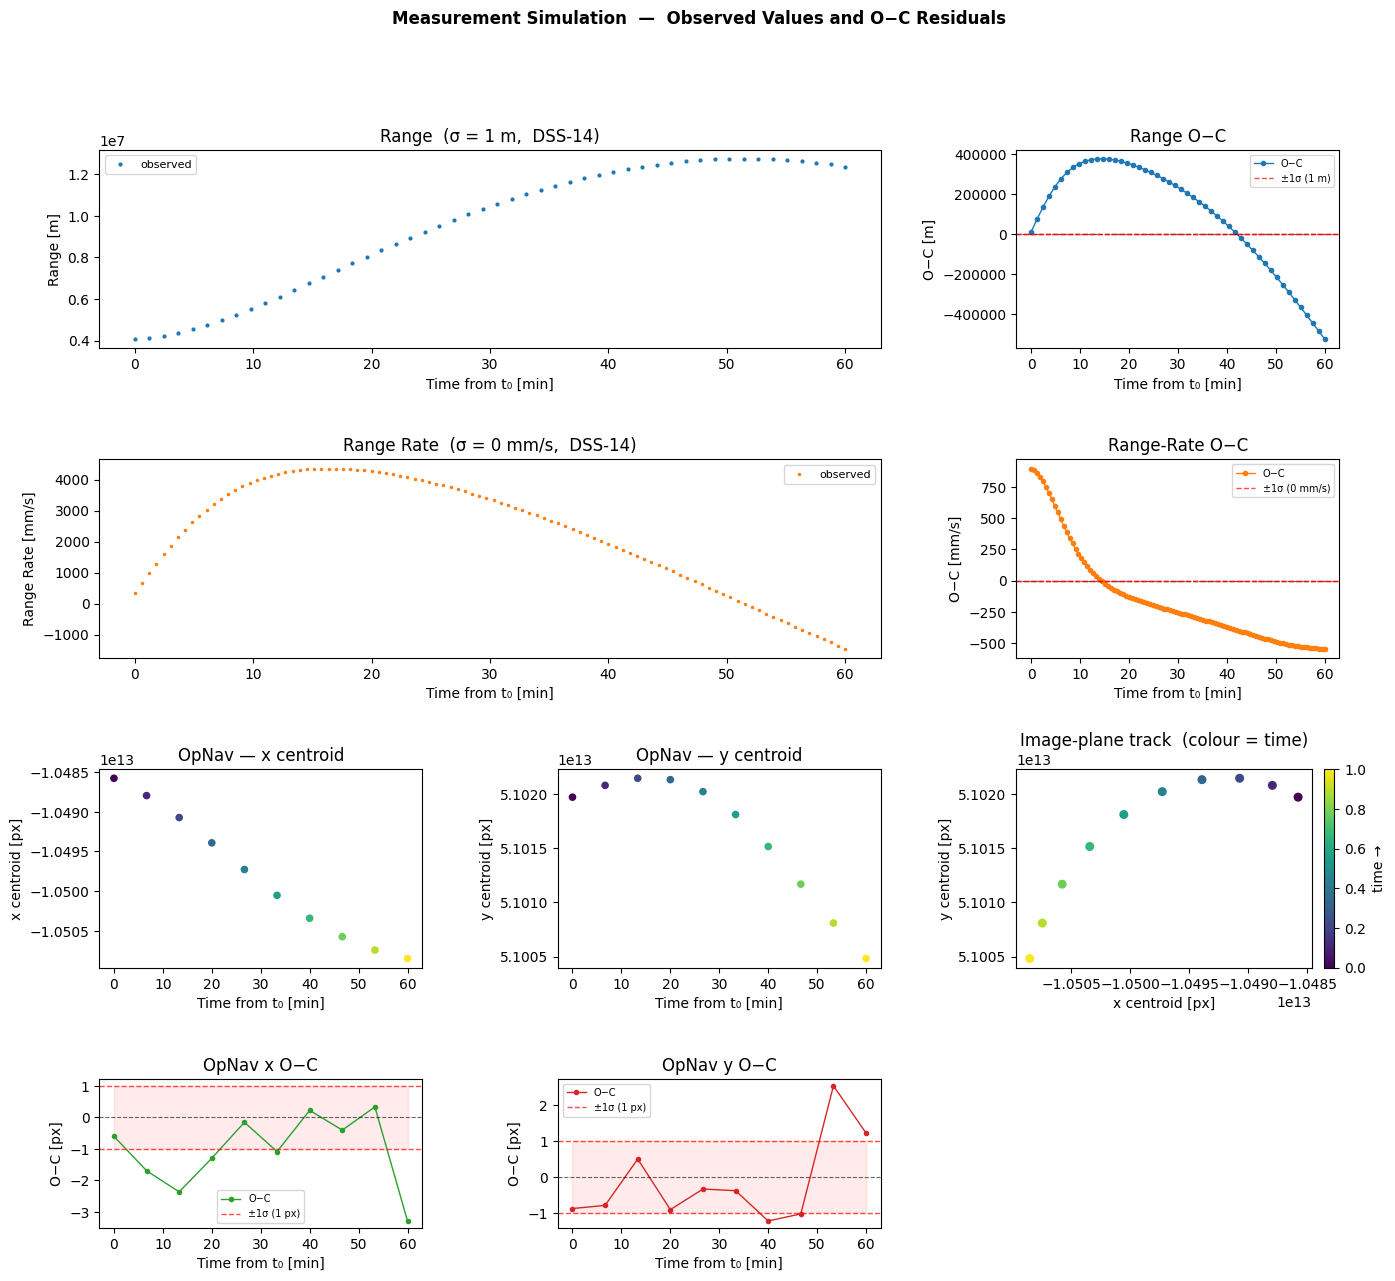

In [11]:
# ── time axes: minutes from arc start ────────────────────────────
def to_min(ep_et):
    return (np.asarray(ep_et.times.values) - t0) / 60.0

t_r  = to_min(ep_range_et)
t_rr = to_min(ep_rangerate_et)
t_o  = to_min(ep_opnav_et)

# ── values ────────────────────────────────────────────────────────
r_vals  = meas_range.quantity.values.ravel()
rr_vals = meas_rangerate.quantity.values.ravel()
o_vals  = meas_opnav.quantity.values           # (n, 2)

# res_range / res_rangerate are already ndarray ravels from §7
sigma_r  = float(range_sigma.values)     * 1e3   # → m
sigma_rr = float(rangerate_sigma.values) * 1e3   # → mm/s
sigma_px = 1.0                                    # pixels

# ── layout: 4 rows × 3 cols ──────────────────────────────────────
# row 0-1: radiometric observed (span 2) | O-C time-series
# row 2  : opnav x obs | opnav y obs | image-plane scatter
# row 3  : opnav x O-C | opnav y O-C | (hidden)
fig = plt.figure(figsize=(16, 14))
fig.suptitle('Measurement Simulation  —  Observed Values and O−C Residuals',
             fontweight='bold', fontsize=12)
gs = GridSpec(4, 3, figure=fig, hspace=0.60, wspace=0.42,
              height_ratios=[1, 1, 1, 0.75])

ax_r    = fig.add_subplot(gs[0, :2])   # range observed
ax_roc  = fig.add_subplot(gs[0, 2])   # range O-C
ax_rr   = fig.add_subplot(gs[1, :2])  # range-rate observed
ax_rroc = fig.add_subplot(gs[1, 2])   # range-rate O-C
ax_opx  = fig.add_subplot(gs[2, 0])   # opnav x centroid
ax_opy  = fig.add_subplot(gs[2, 1])   # opnav y centroid
ax_scat = fig.add_subplot(gs[2, 2])   # image-plane scatter
ax_oxoc = fig.add_subplot(gs[3, 0])   # opnav x O-C
ax_oyoc = fig.add_subplot(gs[3, 1])   # opnav y O-C
fig.add_subplot(gs[3, 2]).set_visible(False)

# helper: draw an O-C residuals panel with ±1σ reference lines
def plot_oc(ax, t, res, sigma, unit_label, color, title):
    ax.plot(t, res, '-o', color=color, ms=3, lw=1.0, label='O−C')
    ax.axhline(0,      color='k',   lw=0.8, ls='--', alpha=0.6)
    ax.axhline( sigma, color='r',   lw=1.0, ls='--', alpha=0.7, label=f'±1σ ({sigma:.0f} {unit_label})')
    ax.axhline(-sigma, color='r',   lw=1.0, ls='--', alpha=0.7)
    ax.fill_between(t, -sigma, sigma, color='r', alpha=0.08)
    ax.set_xlabel('Time from t₀ [min]')
    ax.set_ylabel(f'O−C [{unit_label}]')
    ax.set_title(title)
    ax.legend(fontsize=7)

# ── range ─────────────────────────────────────────────────────────
ax_r.plot(t_r, r_vals * 1e3, '.', color=COLORS[0], ms=4, label='observed')
ax_r.set_xlabel('Time from t₀ [min]'); ax_r.set_ylabel('Range [m]')
ax_r.set_title(f'Range  (σ = {sigma_r:.0f} m,  DSS-14)'); ax_r.legend(fontsize=8)

plot_oc(ax_roc, t_r, res_range * 1e3, sigma_r, 'm', COLORS[0], 'Range O−C')

# ── range rate ────────────────────────────────────────────────────
ax_rr.plot(t_rr, rr_vals * 1e3, '.', color=COLORS[1], ms=3, label='observed')
ax_rr.set_xlabel('Time from t₀ [min]'); ax_rr.set_ylabel('Range Rate [mm/s]')
ax_rr.set_title(f'Range Rate  (σ = {sigma_rr:.0f} mm/s,  DSS-14)'); ax_rr.legend(fontsize=8)

plot_oc(ax_rroc, t_rr, res_rangerate * 1e3, sigma_rr, 'mm/s', COLORS[1], 'Range-Rate O−C')

# ── opnav observed centroids ──────────────────────────────────────
c = plt.cm.viridis(np.linspace(0, 1, len(t_o)))

ax_opx.scatter(t_o, o_vals[:, 0], c=c, s=20, zorder=3)
ax_opx.set_xlabel('Time from t₀ [min]'); ax_opx.set_ylabel('x centroid [px]')
ax_opx.set_title('OpNav — x centroid')

ax_opy.scatter(t_o, o_vals[:, 1], c=c, s=20, zorder=3)
ax_opy.set_xlabel('Time from t₀ [min]'); ax_opy.set_ylabel('y centroid [px]')
ax_opy.set_title('OpNav — y centroid')

sc = ax_scat.scatter(o_vals[:, 0], o_vals[:, 1], c=c, s=30, zorder=3)
ax_scat.set_xlabel('x centroid [px]'); ax_scat.set_ylabel('y centroid [px]')
ax_scat.set_title('Image-plane track  (colour = time)')
plt.colorbar(sc, ax=ax_scat, label='time →', fraction=0.046, pad=0.04)

# ── opnav O-C residuals ───────────────────────────────────────────
plot_oc(ax_oxoc, t_o, res_opnav[:, 0], sigma_px, 'px', COLORS[2], 'OpNav x O−C')
plot_oc(ax_oyoc, t_o, res_opnav[:, 1], sigma_px, 'px', COLORS[3], 'OpNav y O−C')

plt.tight_layout()
plt.show()